# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [4]:
# TODO
#data size 
data_size = df.shape
print("data size:", data_size)
column_names = df.columns
print("column names: ")
print(column_names)
data_types = df.dtypes
print("data types of data: ")
print(data_types)

data size: (891, 15)
column names: 
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
data types of data: 
survived         int64
pclass           int64
sex                str
age            float64
sibsp            int64
parch            int64
fare           float64
embarked           str
class              str
who                str
adult_male        bool
deck               str
embark_town        str
alive              str
alone             bool
dtype: object


## A.2. Missing values & Duplicate data

In [5]:
# TODO
missing_values = df.isna().sum()
if missing_values.sum() == 0: 
    print("Không có dữ liệu nào bị thiếu")
else: 
    print("missing values of data: ")
    print(missing_values[missing_values > 0])
duplicate_data = df.duplicated().sum()
print("duplicate row(all data):", duplicate_data)

missing values of data: 
age            177
embarked         2
deck           688
embark_town      2
dtype: int64
duplicate row(all data): 107


## A.3. Invalid values

In [6]:
# TODO
df
print("fare <= 0:", (df['fare']<=0).sum())
print("age <= 0:", (df['age']<=0).sum())
print("dữ liệu giá vé có vài giá vé bị < 0 (15 giá trị) => chưa được hợp lý")

fare <= 0: 15
age <= 0: 0
dữ liệu giá vé có vài giá vé bị < 0 (15 giá trị) => chưa được hợp lý


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [7]:
# TODO
df['family_size'] = df['sibsp'] + df['parch'] + 1
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [8]:
# TODO

for col in ['fare', 'age']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")
print()

fare: Mean=32.20, Median=14.45, Mode=8.05
age: Mean=29.70, Median=28.00, Mode=24.00



## Group 2 — Dispersion

In [9]:
# TODO
for col in ['fare', 'age']: 
    s = df[col]
    range = s.max() - s.min()
    std = s.std()
    q1, q3 = s.quantile([0.25, 0.75]) 
    iqr = q3 - q1
    cv = std/s.mean()
    print(f"---{col}---");
    print(f"Range={range:.2f}, Std={std:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

---fare---
Range=512.33, Std=49.69, IQR=23.09, CV=1.54
---age---
Range=79.58, Std=14.53, IQR=17.88, CV=0.49


## Group 3 — Location and Shape

P25=7.91, P50=14.45, P75=31.00
Skewness=4.78, Kurtosis=33.20
P25=20.12, P50=28.00, P75=38.00
Skewness=nan, Kurtosis=nan


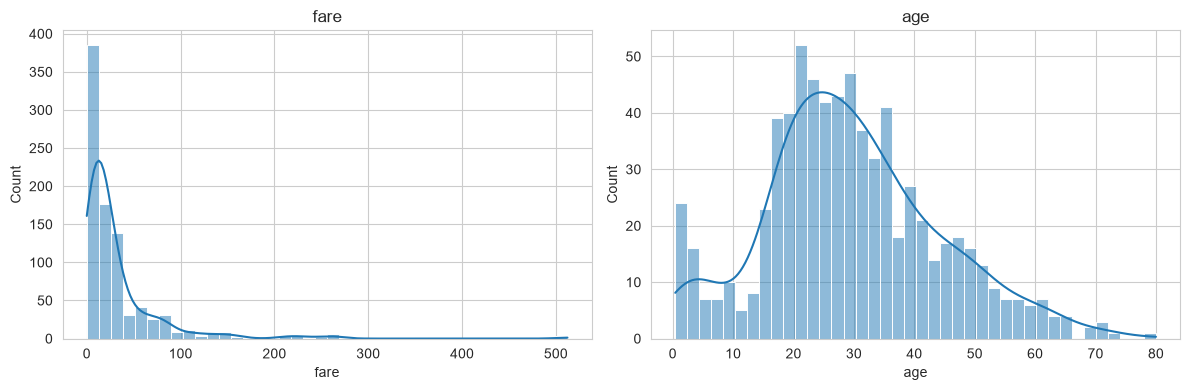

Nhận xét: fare lệch trái và có kurtosis cao hơn hẳn age -> nhiều outlier lợi nhuận cực đoan hơn.


In [ ]:
# TODO
for col in ['fare', 'age']: 
    s = df[col]
    skewness, kurtosis = stats.skew(s), stats.kurtosis(s)
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skewness:.2f}, Kurtosis={kurtosis:.2f}")
    
fig,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['fare'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('fare')
sns.histplot(df['age'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('age')
plt.tight_layout(); plt.show()

print("Nhận xét: fare lệch trái và có kurtosis cao hơn hẳn age -> nhiều outlier lợi nhuận cực đoan hơn.")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [43]:
# TODO
survived_by_class = df.groupby('class')['survived'].mean().sort_values(ascending=False)
print(survived_by_class)
print("hạng vé có tỷ lệ sống sót cao nhất là: ", survived_by_class.index[0])
diff = survived_by_class['First'] - survived_by_class['Second']
diff = survived_by_class[survived_by_class.index[0]] - survived_by_class[survived_by_class.index[-1]]
print("mức chênh lệch so với hạng thấp nhất là: ", diff.round(4))

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64
hạng vé có tỷ lệ sống sót cao nhất là:  First
mức chênh lệch so với hạng thấp nhất là:  0.3873


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [56]:
# TODO
class_by_survived = df.groupby('class')['survived'].mean().sort_values(ascending=False)
range_of_class = class_by_survived[class_by_survived.index[0]] - class_by_survived[class_by_survived.index[-1]]
sex_by_survived = df.groupby('sex')['survived'].mean()
range_of_sex = sex_by_survived[sex_by_survived.index[0]] - sex_by_survived[sex_by_survived.index[-1]]
print("khoảng chênh lệch theo hạng vé là: ", range_of_class)
print("khoảng chênh lệch theo giới tính là: ", range_of_sex)
if range_of_class > range_of_sex: 
    print("hạng vé ảnh hưởng đến sống sót mạnh hơn")
else: 
    print("giới tính ảnh hưởng đến sống sót mạnh hơn")

khoảng chênh lệch theo hạng vé là:  0.3872671041713812
khoảng chênh lệch theo giới tính là:  0.5531300709799203
giới tính ảnh hưởng đến sống sót mạnh hơn


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [64]:
# TODO
group_by_survived = df.groupby('survived')['fare'].mean()
print(group_by_survived)
print('Giá vé trung bình: ')
print("giá vé nhóm sống sót: ", group_by_survived[group_by_survived.index[1]])
print("giá vé nhóm thiệt mạng: ", group_by_survived[group_by_survived.index[0]])
diff = group_by_survived[group_by_survived.index[0]] - group_by_survived[group_by_survived.index[1]]
print("ta thấy giá vé nhóm sống sót cao hơn nhóm thiệt mạng là", diff, "điều này cho thấy vé càng đắt thì tỷ lệ sống sót càng cao")

survived
0    22.117887
1    48.395408
Name: fare, dtype: float64
Giá vé trung bình: 
giá vé nhóm sống sót:  48.39540760233918
giá vé nhóm thiệt mạng:  22.117886885245902
ta thấy giá vé nhóm sống sót cao hơn nhóm thiệt mạng là -26.27752071709328 điều này cho thấy vé càng đắt thì tỷ lệ sống sót càng cao


## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [74]:
# TODO
family_sizes = df.groupby('family_size')['survived'].mean().sort_values(ascending=False)
print(family_sizes)
print("tỷ lệ sống sót cao nhất là: ", family_sizes[family_sizes.index[0]], "thuộc về gia đình 4 người")
print("kết luận rằng: gia đình có số người là 4 thì tỷ lệ sống sót cao nhất")

family_size
4     0.724138
3     0.578431
2     0.552795
7     0.333333
1     0.303538
5     0.200000
6     0.136364
8     0.000000
11    0.000000
Name: survived, dtype: float64
tỷ lệ sống sót cao nhất là:  0.7241379310344828 thuộc về gia đình 4 người
kết luận rằng: gia đình có số người là 4 thì tỷ lệ sống sót cao nhất


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [80]:
# TODO
embark_town_by_survived = df.groupby('embark_town')['survived'].mean().sort_values(ascending=False)
print(embark_town_by_survived)
print("cảng lên tàu có tỷ lệ sống sót cao nhất là cảng:", embark_town_by_survived.index[0], "với tỷ lệ sống sót là: ", embark_town_by_survived[embark_town_by_survived.index[0]])

embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: survived, dtype: float64
cảng lên tàu có tỷ lệ sống sót cao nhất là cảng: Cherbourg với tỷ lệ sống sót là:  0.5535714285714286


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

*(Viết insight của bạn vào đây...)*

Phân tích dữ liệu Titanic cho thấy Giới tính là yếu tố quyết định hàng đầu khi tỷ lệ sống sót của nữ giới vượt trội so với nam giới (chênh lệch 55.31%). Bên cạnh đó, địa vị tài chính đóng vai trò rất lớn khi hành khách mua vé Hạng nhất và trả giá vé cao có khả năng sống sót tốt hơn hẳn Hạng ba. Về quy mô đi cùng, nhóm gia đình 4 người có lợi thế an toàn cao nhất (72.41%), trong khi đi đơn độc hoặc gia đình quá đông đều giảm cơ hội thoát hiểm. Cuối cùng, cảng Cherbourg ghi nhận tỷ lệ sống cao nhất (55.36%) do tập trung phần lớn hành khách thuộc phân khúc cao cấp. Tóm lại, cơ hội sống sót cao nhất thuộc về Nữ giới đi Hạng nhất cùng gia đình nhỏ (2–4 người).